In [1]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_csv("powerplant_data .csv")

In [3]:
  df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# ATM== Temperature
# V==>VACUUM 
# AP==>PRESSURE
# RH==>HUMIDITY

# PE==>PRODUCED ENERGY


In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
x=df.drop("PE",axis=1)
y=df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    x,y ,test_size=0.2,random_state=42)

In [9]:
df.shape

(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler() 
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [12]:
import torch
import torch.nn as nn

X_train_tensor=torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)


X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)


In [13]:
print(type(X_train_scaled))
print(type(y_train))
print (y_train.shape)

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
(7654,)


In [14]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor, y_test_tensor)

In [15]:

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [16]:
class ANN(nn.Module):                         #capital M hona chiye
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),  

            #2nd hidden layer 
            nn.Linear(6,6),
            nn.ReLU(),

            #output layer
            nn.Linear(6,1),
        )

    def forward(self,x): 
        return self.model(x)
            

            

In [17]:
import torch.optim as optim

model=ANN()

# loss,optimizer            yin dono ko itself chose kar sakte hai hows you want to chose
crietrion =nn.MSELoss()
optimizer =optim.Adam(model.parameters())        # model.parameters se sare optimaizer parameter pass 
                                                 # ho gye like weight bias etc.

loss fnx ke sath  backword propgation autometic handal ho jata hai by Autograd ==>
Autonatic gradiand;

In [37]:
  # Train the Ann
train_losses=[]
val_losses=[]
epochs=100

best_val_loss=float("inf")


for epoch in range(epochs):
    model.train()
    running_loss=0.0

    for xb, yb in train_loader:
        #xb=features of 1 batch
        #yb= labels of 1 batch
        optimizer.zero_grad()

        outputs=model(xb)
        loss=crietrion(outputs,yb)
        loss.backward()
        optimizer.step()

        running_loss +=loss.item()

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)


    #validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():#no gradients compute
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=crietrion(outputs,yb)
            running_val_loss+=loss

    epoch_val_loss =running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs}==>train loss= {epoch_train_loss} & val loss = {epoch_val_loss}")


    if epoch_val_loss < best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") #model file ko .pt ya .pth extention se save karte hai

epoch 1/100==>train loss= 19.728756109873455 & val loss = 18.121580123901367
epoch 2/100==>train loss= 19.597491161028543 & val loss = 18.656217575073242
epoch 3/100==>train loss= 19.55862024029096 & val loss = 17.688640594482422
epoch 4/100==>train loss= 19.64757021665573 & val loss = 17.88665771484375
epoch 5/100==>train loss= 19.556225887934367 & val loss = 17.83149528503418
epoch 6/100==>train loss= 19.514663275082906 & val loss = 17.681936264038086
epoch 7/100==>train loss= 20.76956708629926 & val loss = 18.603179931640625
epoch 8/100==>train loss= 19.81095207929611 & val loss = 18.07941436767578
epoch 9/100==>train loss= 19.560776178042094 & val loss = 18.14021873474121
epoch 10/100==>train loss= 19.6491637190183 & val loss = 17.728830337524414
epoch 11/100==>train loss= 19.735876935720444 & val loss = 18.29920196533203
epoch 12/100==>train loss= 19.444117307662964 & val loss = 17.659114837646484
epoch 13/100==>train loss= 19.564818902810416 & val loss = 18.012365341186523
epoch 

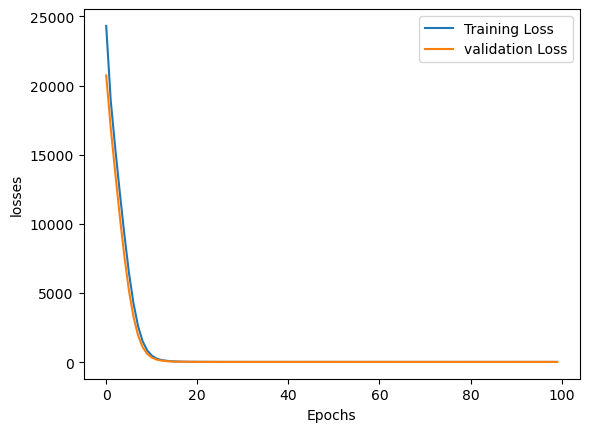

In [33]:
import matplotlib.pyplot as plt
loss_df=pd.DataFrame({
    "Training Loss":train_losses,
    "validation Loss": val_losses
})
plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["validation Loss"],label="validation Loss")

plt.xlabel("Epochs")
plt.ylabel("losses")

plt.legend()

In [ ]:

model save karte samye learnning parametar save hote hai 

In [36]:
#Loding the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [40]:
#Evaluate model
model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse_loss=crietrion(train_preds,y_train_tensor)
    test_mse_loss=crietrion(test_preds,y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testint MSE:",test_mse_loss.item())

Training MSE: 19.271507263183594
Testint MSE: 17.758150100708008


In [41]:
from sklearn.metrics import r2_score
print("r^2 score=",r2_score(y_test,test_preds))

r^2 score= 0.9379398525753988


In [46]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["predicted value"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Value"])

pd.concat([predicted_df, actual_df],axis=1)

,predicted value,Actual Value
0,434.102661,433.27
1,435.814941,438.16
2,461.309448,458.42
3,477.154938,480.82
4,433.661926,441.41
...,...,...
1909,451.313202,456.70
1910,432.860657,438.04
1911,468.123230,467.80
1912,433.091553,437.14
